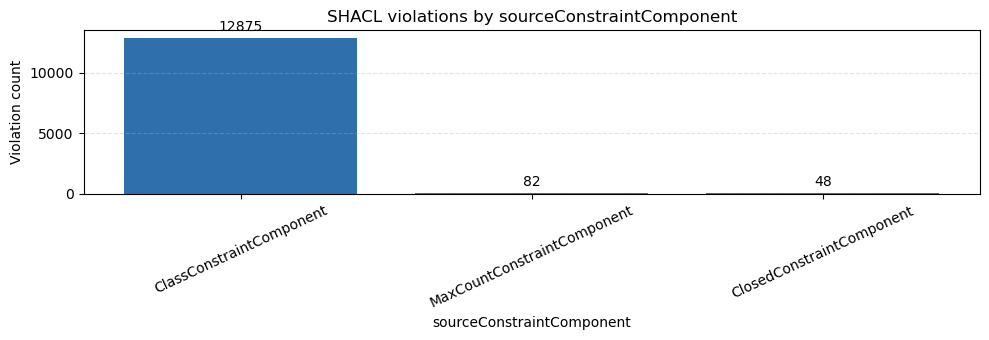

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt

workspace_root = Path.cwd()
if not (workspace_root / "experiments").exists() and (workspace_root.parent / "experiments").exists():
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import experiments.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
component_counts = shacl_violation_distribution.collect_source_constraint_component_counts(str(run_directory))

if not component_counts:
    print("No SHACL violations found.")
else:
    ordered_items = component_counts.most_common()
    labels = [label for label, _ in ordered_items]
    values = [value for _, value in ordered_items]

    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.5 * len(labels))))
    bars = ax.bar(labels, values, color="#2f6fab")
    ax.set_title("SHACL violations by sourceConstraintComponent")
    ax.set_xlabel("sourceConstraintComponent")
    ax.set_ylabel("Violation count")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{int(height)}",
            (bar.get_x() + bar.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 3),
            textcoords="offset points",
        )

    plt.tight_layout()
    plt.show()

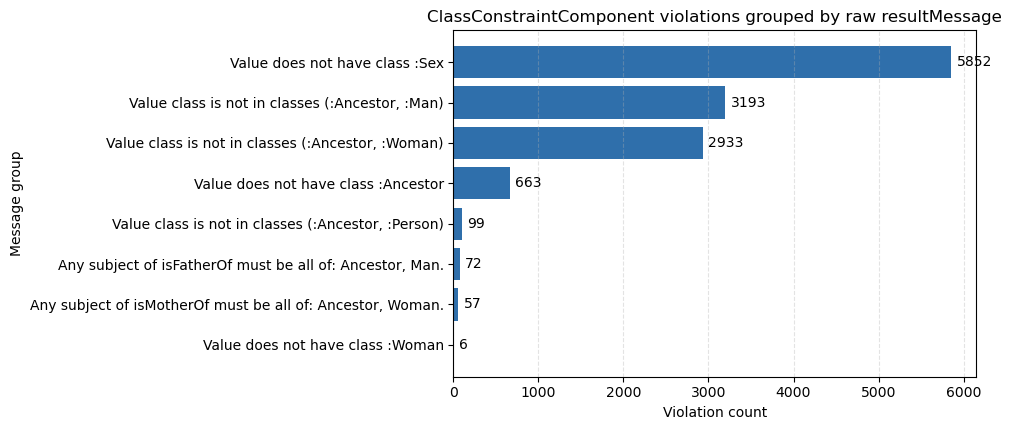

In [2]:
from pathlib import Path
import importlib
import sys
from textwrap import shorten

import matplotlib.pyplot as plt

workspace_root = Path.cwd()
if not (workspace_root / "experiments").exists() and (workspace_root.parent / "experiments").exists():
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import experiments.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
message_counts = shacl_violation_distribution.collect_class_constraint_messages(str(run_directory))

if not message_counts:
    print("No ClassConstraintComponent violations found.")
else:
    ordered_items = message_counts.most_common()
    labels = [shorten(label, width=90, placeholder="...") for label, _ in ordered_items]
    values = [value for _, value in ordered_items]

    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.55 * len(labels))))
    bars = ax.barh(labels, values, color="#2f6fab")
    ax.set_title("ClassConstraintComponent violations grouped by raw resultMessage")
    ax.set_xlabel("Violation count")
    ax.set_ylabel("Message group")
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            f"{int(width)}",
            (width, bar.get_y() + bar.get_height() / 2),
            ha="left",
            va="center",
            fontsize=10,
            xytext=(4, 0),
            textcoords="offset points",
        )

    plt.tight_layout()
    plt.show()

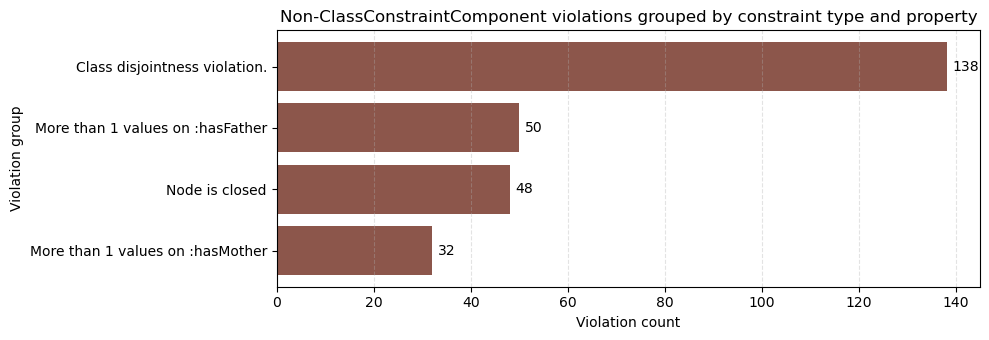

In [4]:
from pathlib import Path
import importlib
import sys
from textwrap import shorten

import matplotlib.pyplot as plt

workspace_root = Path.cwd()
if not (workspace_root / "experiments").exists() and (workspace_root.parent / "experiments").exists():
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import experiments.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
other_message_counts = shacl_violation_distribution.collect_non_class_constraint_messages(str(run_directory))
reorganized_counts = shacl_violation_distribution.reorganize_non_class_violations(other_message_counts)

if not reorganized_counts:
    print("No non-ClassConstraintComponent violations found.")
else:
    ordered_items = reorganized_counts.most_common()
    labels = [shorten(label, width=90, placeholder="...") for label, _ in ordered_items]
    values = [value for _, value in ordered_items]

    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.55 * len(labels))))
    bars = ax.barh(labels, values, color="#8c564b")
    ax.set_title("Non-ClassConstraintComponent violations grouped by constraint type and property")
    ax.set_xlabel("Violation count")
    ax.set_ylabel("Violation group")
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            f"{int(width)}",
            (width, bar.get_y() + bar.get_height() / 2),
            ha="left",
            va="center",
            fontsize=10,
            xytext=(4, 0),
            textcoords="offset points",
        )

    plt.tight_layout()
    plt.show()

In [11]:
from pathlib import Path
import importlib
import sys

workspace_root = Path.cwd()
if not (workspace_root / "experiments").exists() and (workspace_root.parent / "experiments").exists():
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import experiments.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
violations_by_message = shacl_violation_distribution.collect_non_class_violations_by_task(str(run_directory))

# Filter for class disjointness violations (case-insensitive search)
class_disjointness_tasks = set()
for message, tasks in violations_by_message.items():
    if "disjoint" in message.lower():
        class_disjointness_tasks.update(tasks)

# Filter for max count violations
max_count_tasks = set()
for message, tasks in violations_by_message.items():
    if "More than" in message:
        max_count_tasks.update(tasks)

print(f"Number of different tasks with class disjointness violations: {len(class_disjointness_tasks)}")
print(f"Number of different tasks with max count violations: {len(max_count_tasks)}")

Number of different tasks with class disjointness violations: 6
Number of different tasks with max count violations: 21
